# Berry Island Survival - ML Final Project

I'm on an island, rations are running out, and there are berry bushes everywhere. I've collected measurements about the plants and now I need to figure out what's edible, what species they are, and how big the berries get.

Four parts: clustering, edibility classification, species identification, berry size regression.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100
sns.set_style("whitegrid")
print("Ready to go.")

Ready to go.


In [2]:
# Load all the datasets
df_clustering = pd.read_json("s-001070_clustering.json")
df_edible = pd.read_json("s-001070_edible.json")
df_species = pd.read_json("s-001070_species.json")
df_complete = pd.read_json("s-001070_complete.json")
df_berry = pd.read_json("s-001070_berry.json")
df_leaf = pd.read_json("s-001070_leaf.json")
df_petal = pd.read_json("s-001070_petal.json")

# Quick sanity check
print("Dataset sizes:")
for name, df in [("clustering", df_clustering), ("edible", df_edible), ("species", df_species),
                  ("complete", df_complete), ("berry", df_berry), ("leaf", df_leaf), ("petal", df_petal)]:
    print(f"  {name:>12}: {df.shape[0]:>4} rows, {df.shape[1]:>2} columns — {list(df.columns)}")

Dataset sizes:
    clustering:  500 rows,  6 columns — ['age', 'leaf_size', 'berry_size', 'petal_size', 'soil_quality', 'height']
        edible:  500 rows,  4 columns — ['leaf_shape', 'petal_colour', 'berry_colour', 'edible']
       species:  500 rows,  4 columns — ['leaf_shape', 'petal_colour', 'berry_colour', 'species']
      complete:  500 rows, 11 columns — ['age', 'leaf_size', 'berry_colour', 'berry_size', 'leaf_shape', 'petal_colour', 'petal_size', 'height', 'edible', 'soil_quality', 'species']
         berry:  500 rows,  7 columns — ['age', 'height', 'soil_quality', 'berry_colour', 'berry_size', 'edible', 'species']
          leaf:  500 rows,  7 columns — ['age', 'height', 'soil_quality', 'leaf_shape', 'leaf_size', 'edible', 'species']
         petal:  500 rows,  7 columns — ['age', 'height', 'soil_quality', 'petal_colour', 'petal_size', 'edible', 'species']


In [3]:
# Let me get a feel for the numeric data first
df_clustering.describe().round(2)

,age,leaf_size,berry_size,petal_size,soil_quality,height
count,500.00,500.00,500.00,500.00,500.00,500.00
mean,4.90,24.81,7.31,3.17,4.44,118.53
std,2.84,11.31,2.82,1.25,0.87,100.45
min,0.02,9.55,0.00,0.61,3.00,0.61
25%,2.56,16.04,6.53,2.21,3.66,41.91
50%,4.89,21.13,7.85,3.11,4.42,92.90
75%,7.29,32.05,9.04,4.02,5.17,164.92
max,9.98,64.27,12.56,6.14,6.00,553.28


---
# Part 1: Clustering

I have six numeric features per plant but no labels. Can I find natural groups?

I'll use K-Means as the main approach. It's the standard starting point for clustering and works by iteratively assigning points to nearest centroids (EM-style). It assumes roughly spherical clusters, which is a reasonable first guess. I'll use the elbow method and silhouette scores to pick k, and also try hierarchical clustering as a cross-check since it doesn't require choosing k upfront and can reveal structure via the dendrogram.

Important: need to standardize first. K-Means uses Euclidean distance, and the features are on totally different scales (height ~0-600 vs soil_quality ~1-8). Without scaling, height would dominate everything.

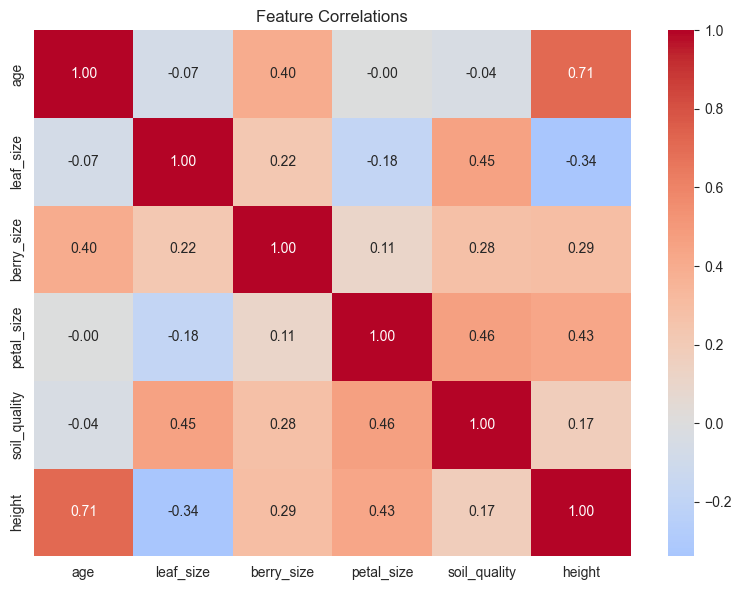

In [4]:
# Correlation heatmap — are any features strongly related?
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(df_clustering.corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f', ax=ax)
ax.set_title("Feature Correlations")
plt.tight_layout()
plt.show()

# age and height seem like they should correlate — older plants are taller
# let's see what else pops out

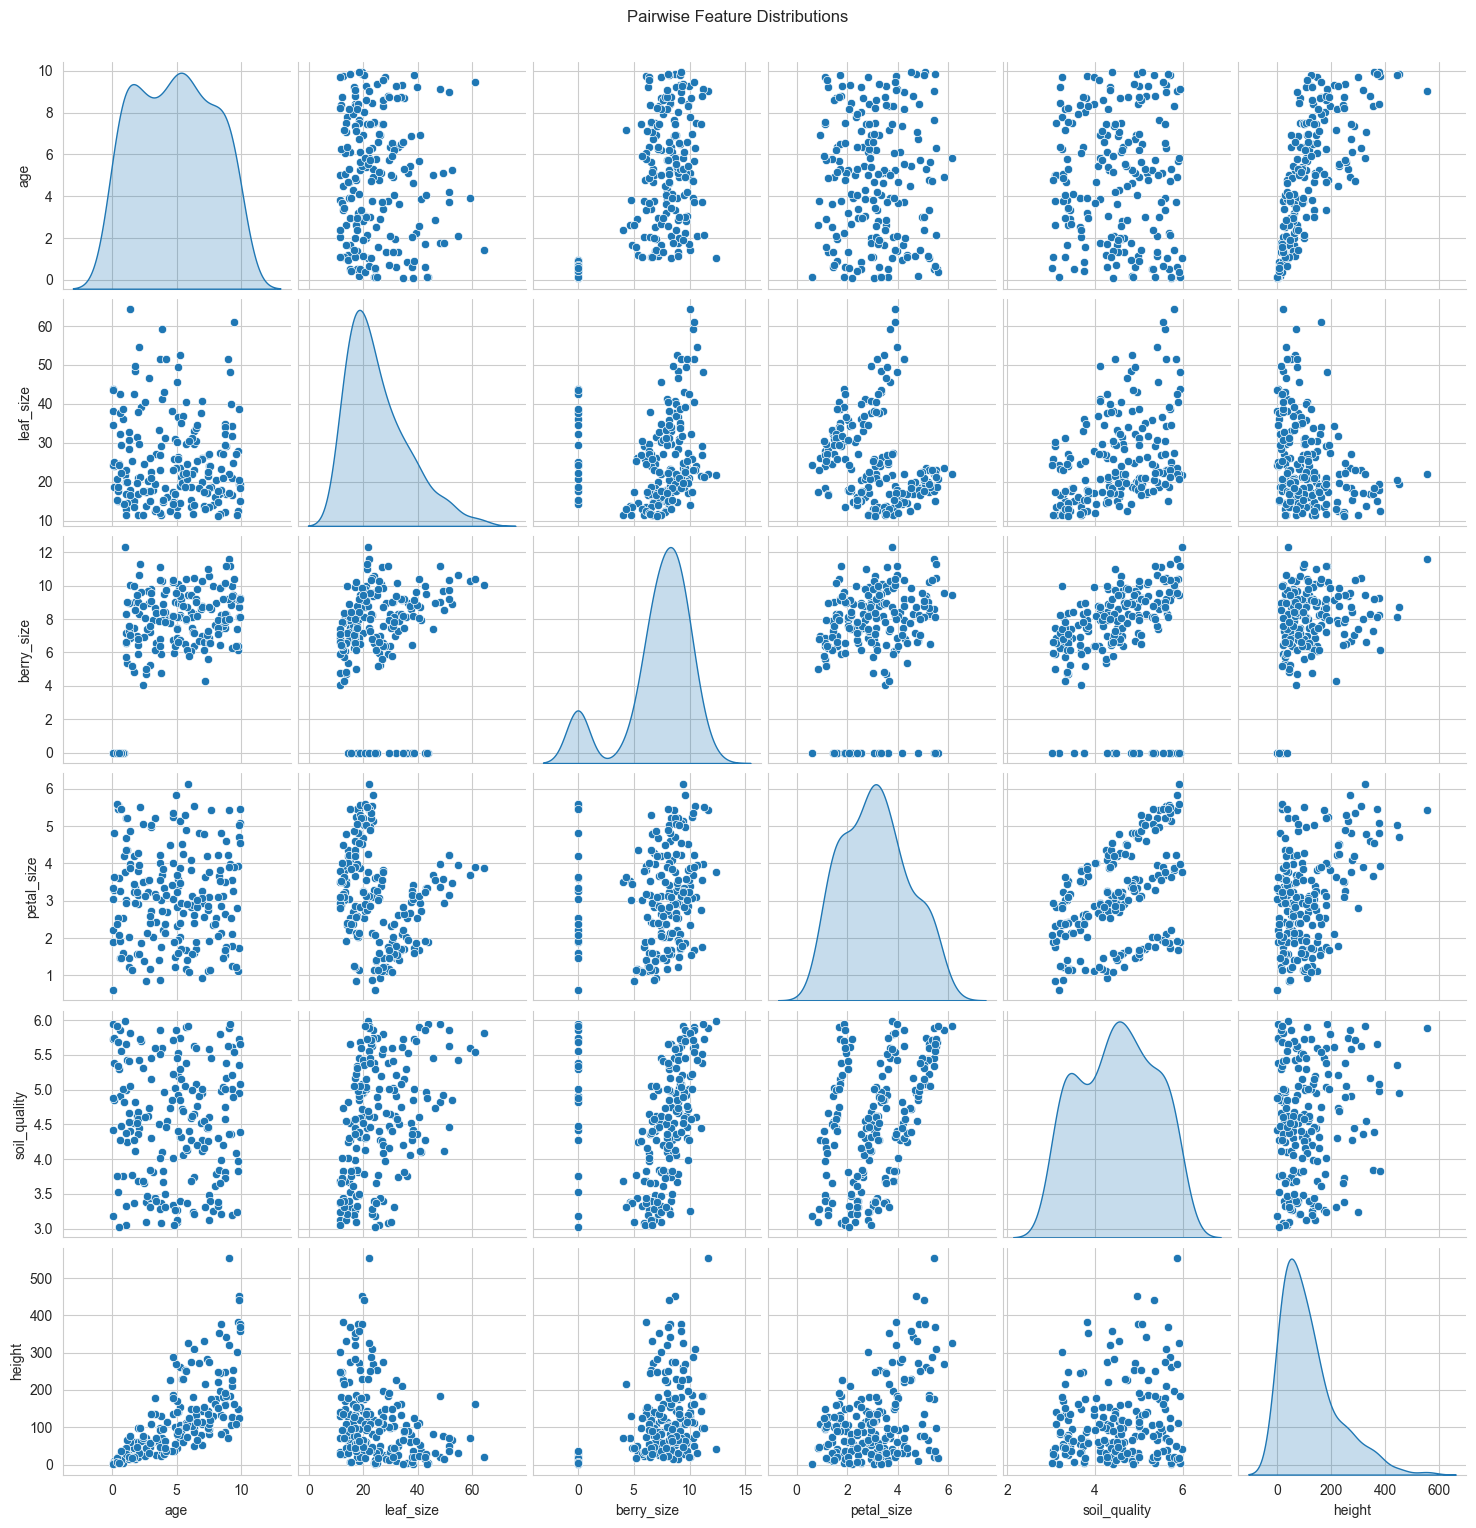

In [5]:
# Pairplot to eyeball potential clusters
# I'll sample if the dataset is large, otherwise plot everything
sample = df_clustering.sample(min(200, len(df_clustering)), random_state=42)
sns.pairplot(sample, diag_kind='kde')
plt.suptitle("Pairwise Feature Distributions", y=1.02)
plt.show()

### Picking k

Elbow method (plot inertia vs k, look for the bend) and silhouette score (how well-separated are the clusters, -1 to 1). Trying k=2 through 10.

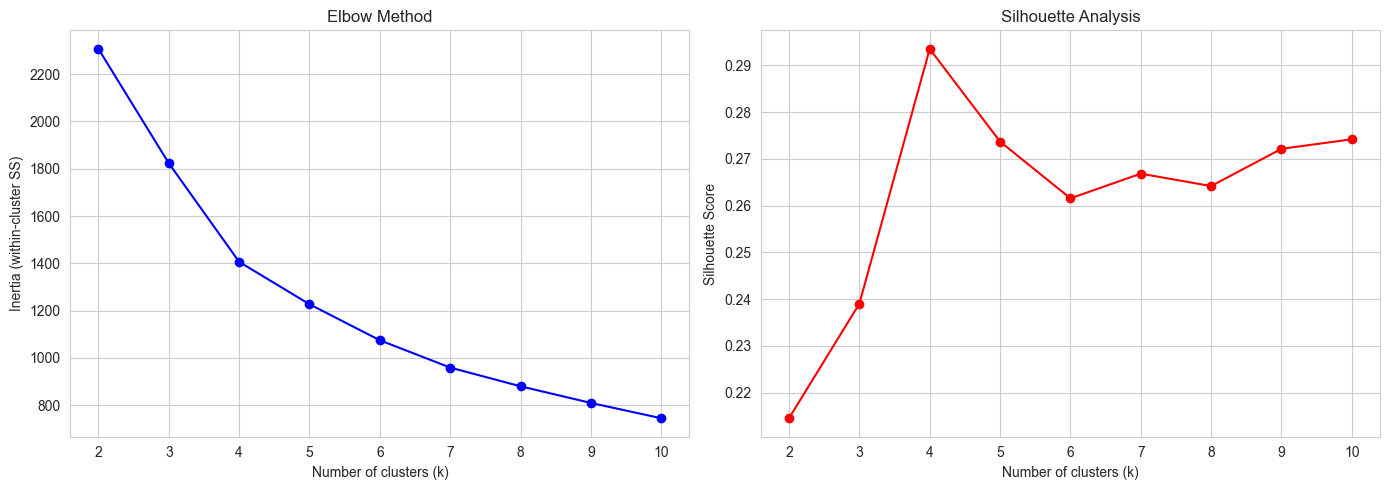

Best silhouette score: 0.294 at k=4


In [6]:
# Standardize features — crucial for distance-based methods
scaler = StandardScaler()
X_clust = scaler.fit_transform(df_clustering)

# Try k = 2 through 10
K_range = range(2, 11)
inertias = []
silhouettes = []

for k in K_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X_clust)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_clust, labels))

# Plot both metrics side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(K_range, inertias, 'bo-')
ax1.set_xlabel('Number of clusters (k)')
ax1.set_ylabel('Inertia (within-cluster SS)')
ax1.set_title('Elbow Method')
ax1.set_xticks(list(K_range))

ax2.plot(K_range, silhouettes, 'ro-')
ax2.set_xlabel('Number of clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Analysis')
ax2.set_xticks(list(K_range))

plt.tight_layout()
plt.show()

best_k = list(K_range)[np.argmax(silhouettes)]
print(f"Best silhouette score: {max(silhouettes):.3f} at k={best_k}")

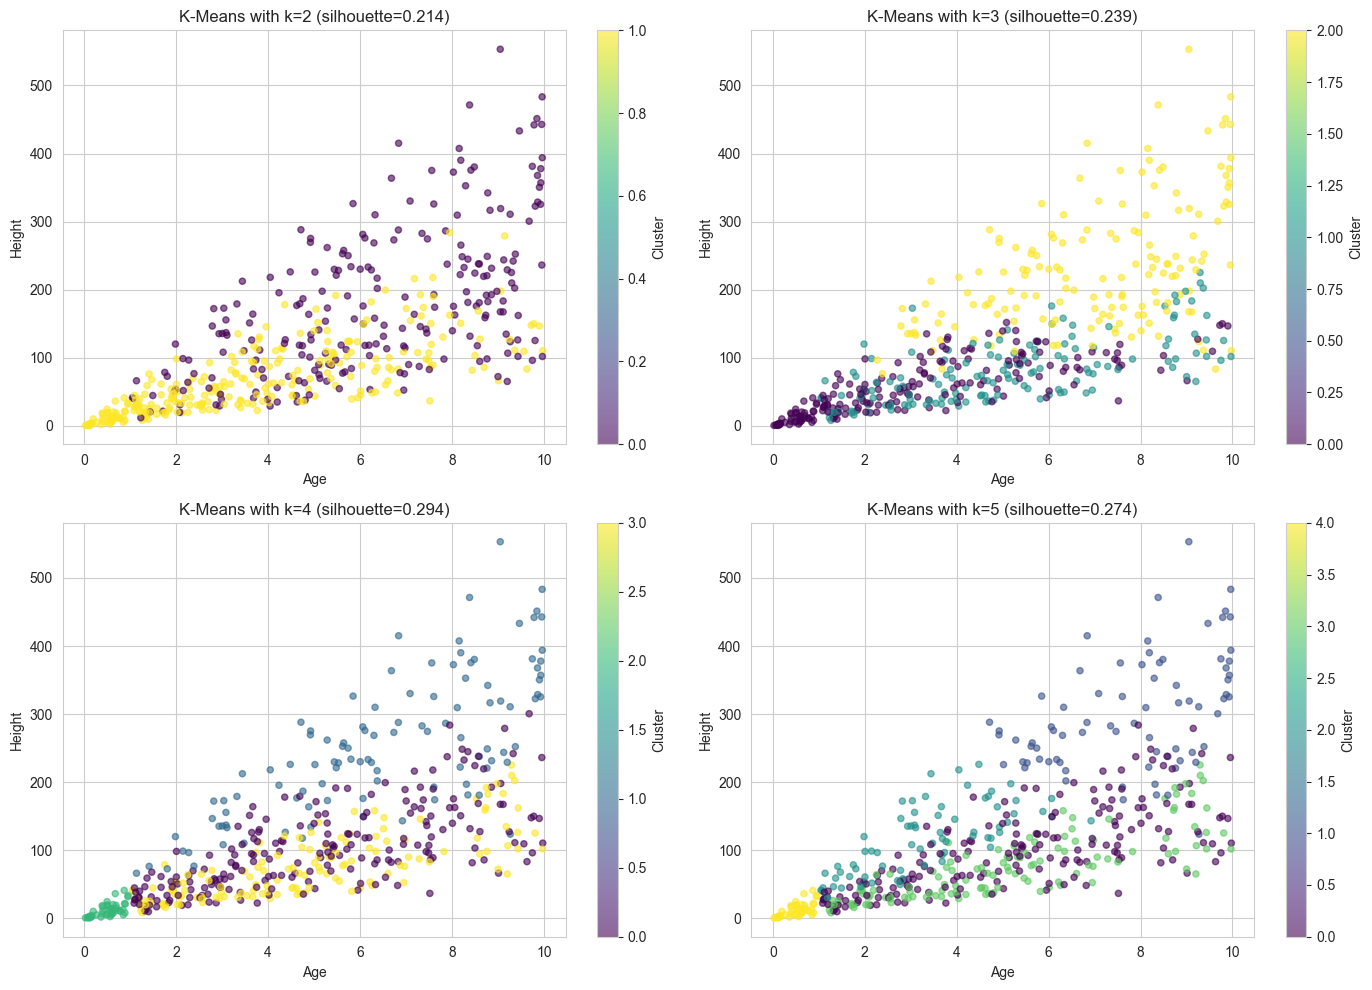

In [7]:
# Let me visualize the clustering for k=2, 3, 4, 5 to compare
# I'll project onto the two most informative features for visualization
# (using age vs height since those are intuitive and likely correlated with species)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, k in enumerate([2, 3, 4, 5]):
    ax = axes[idx // 2][idx % 2]
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X_clust)
    sil = silhouette_score(X_clust, labels)
    
    scatter = ax.scatter(df_clustering['age'], df_clustering['height'], 
                        c=labels, cmap='viridis', alpha=0.6, s=20)
    ax.set_xlabel('Age')
    ax.set_ylabel('Height')
    ax.set_title(f'K-Means with k={k} (silhouette={sil:.3f})')
    plt.colorbar(scatter, ax=ax, label='Cluster')

plt.tight_layout()
plt.show()

### Different feature subsets

Not all features might be useful. Including noisy ones dilutes the distance signal, which is a problem for K-Means. Let me compare some combinations.

In [8]:
# Compare clustering quality across different feature subsets
feature_combos = {
    "All features": list(df_clustering.columns),
    "Age + Height only": ["age", "height"],
    "Size features (leaf, berry, petal)": ["leaf_size", "berry_size", "petal_size"],
    "Age + Height + Soil": ["age", "height", "soil_quality"],
    "Berry + Petal + Leaf size": ["berry_size", "petal_size", "leaf_size"],
}

print(f"{'Feature Set':<35} | {'k':>2} | {'Silhouette':>10}")
print("-" * 55)

best_results = {}
for name, cols in feature_combos.items():
    X_sub = StandardScaler().fit_transform(df_clustering[cols])
    best_sil = -1
    best_k_sub = 2
    for k in range(2, 8):
        labels = KMeans(n_clusters=k, n_init=10, random_state=42).fit_predict(X_sub)
        sil = silhouette_score(X_sub, labels)
        if sil > best_sil:
            best_sil = sil
            best_k_sub = k
    best_results[name] = (best_k_sub, best_sil)
    print(f"{name:<35} | {best_k_sub:>2} | {best_sil:>10.3f}")

Feature Set                         |  k | Silhouette
-------------------------------------------------------
All features                        |  4 |      0.294
Age + Height only                   |  2 |      0.502


Size features (leaf, berry, petal)  |  3 |      0.404
Age + Height + Soil                 |  2 |      0.349


Berry + Petal + Leaf size           |  3 |      0.404


### Growth rate

The assignment asks about growth_rate = height / age. Makes sense — two plants with the same height but different ages are growing at different rates, which could be a better species indicator. Need to clip age > 0.1 to avoid division by near-zero.

In [9]:
# Add growth rate as a derived feature
df_clust_enhanced = df_clustering.copy()
df_clust_enhanced['growth_rate'] = df_clust_enhanced['height'] / df_clust_enhanced['age'].clip(lower=0.1)

# Compare: original features vs. with growth rate
feature_sets = {
    "Original (all 6)": list(df_clustering.columns),
    "With growth_rate": list(df_clustering.columns) + ['growth_rate'],
    "growth_rate + leaf + berry + petal": ['growth_rate', 'leaf_size', 'berry_size', 'petal_size'],
    "growth_rate + soil_quality": ['growth_rate', 'soil_quality'],
}

print(f"{'Feature Set':<40} | {'k':>2} | {'Silhouette':>10}")
print("-" * 60)

for name, cols in feature_sets.items():
    X_sub = StandardScaler().fit_transform(df_clust_enhanced[cols])
    best_sil = -1
    best_k_sub = 2
    for k in range(2, 8):
        labels = KMeans(n_clusters=k, n_init=10, random_state=42).fit_predict(X_sub)
        sil = silhouette_score(X_sub, labels)
        if sil > best_sil:
            best_sil = sil
            best_k_sub = k
    print(f"{name:<40} | {best_k_sub:>2} | {best_sil:>10.3f}")

Feature Set                              |  k | Silhouette
------------------------------------------------------------
Original (all 6)                         |  4 |      0.294


With growth_rate                         |  4 |      0.285
growth_rate + leaf + berry + petal       |  7 |      0.368
growth_rate + soil_quality               |  3 |      0.446


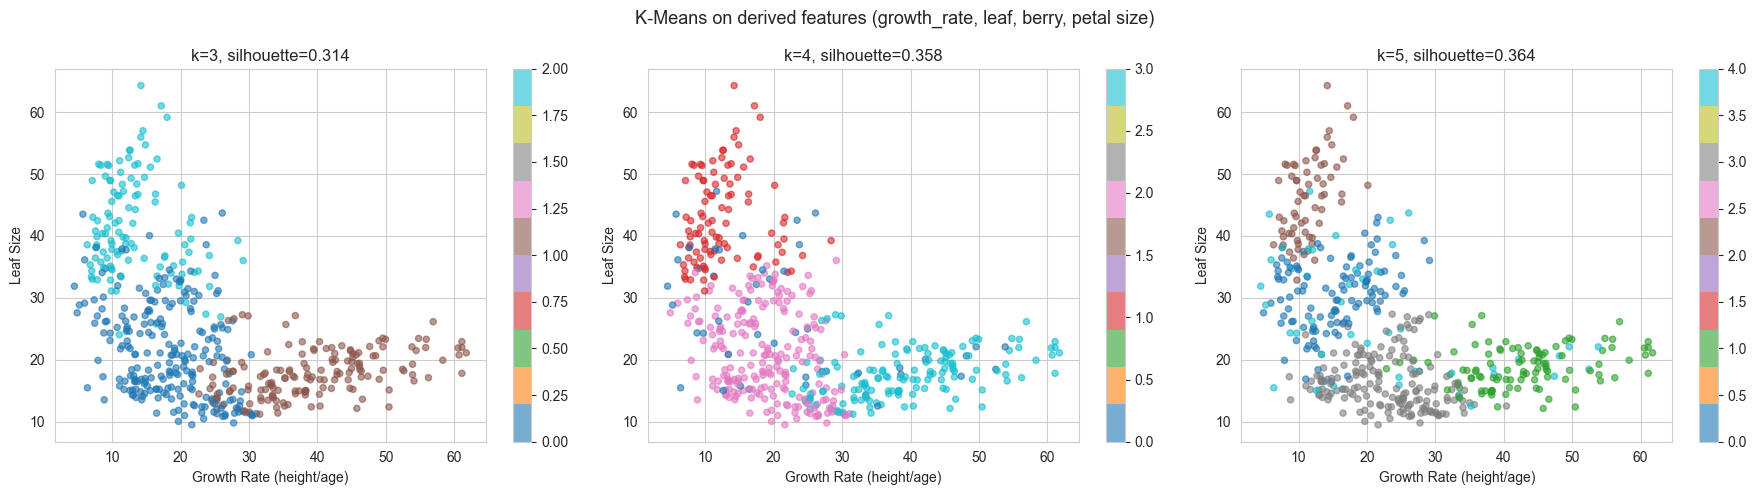

In [10]:
# Visualize the best clustering with growth_rate
# Let me plot growth_rate vs leaf_size colored by cluster labels
X_gr = StandardScaler().fit_transform(df_clust_enhanced[['growth_rate', 'leaf_size', 'berry_size', 'petal_size']])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, k in enumerate([3, 4, 5]):
    labels = KMeans(n_clusters=k, n_init=10, random_state=42).fit_predict(X_gr)
    sil = silhouette_score(X_gr, labels)
    ax = axes[idx]
    scatter = ax.scatter(df_clust_enhanced['growth_rate'], df_clust_enhanced['leaf_size'],
                        c=labels, cmap='tab10', alpha=0.6, s=20)
    ax.set_xlabel('Growth Rate (height/age)')
    ax.set_ylabel('Leaf Size')
    ax.set_title(f'k={k}, silhouette={sil:.3f}')
    plt.colorbar(scatter, ax=ax)

plt.suptitle("K-Means on derived features (growth_rate, leaf, berry, petal size)", fontsize=13)
plt.tight_layout()
plt.show()

### Hierarchical clustering

K-Means needs k upfront and assumes spherical clusters. Hierarchical clustering builds a tree of merges, so I can see the structure at all levels. Using Ward's linkage (minimizes within-cluster variance, similar idea to K-Means).

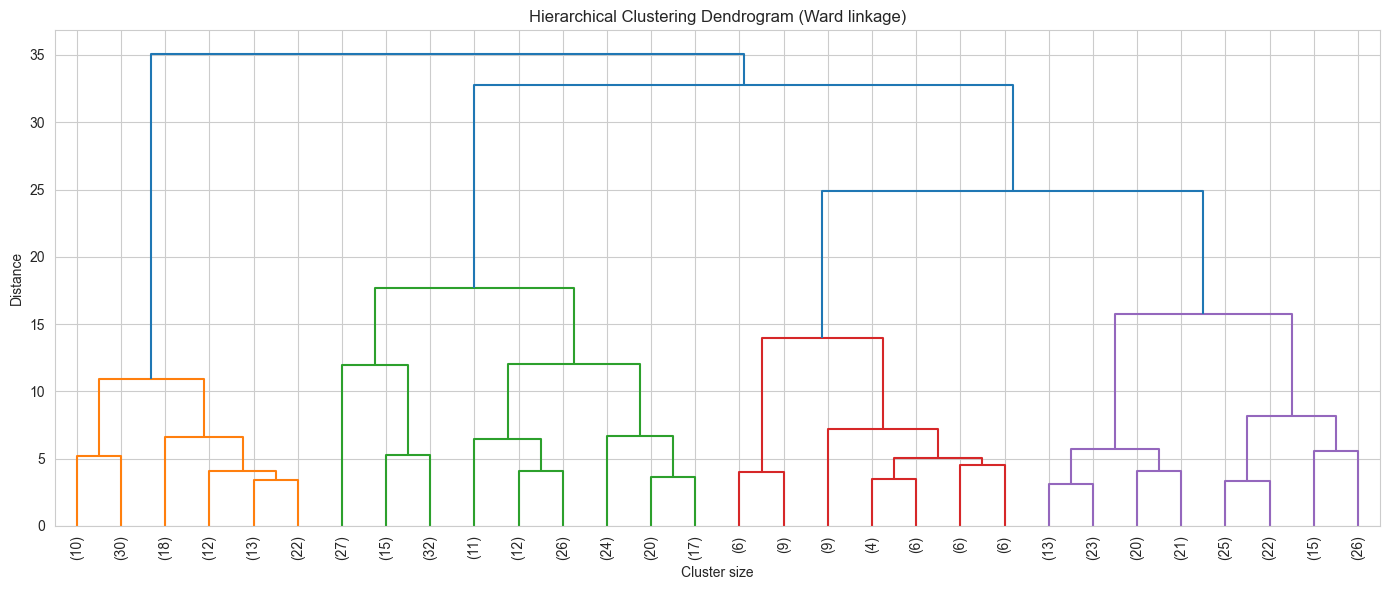

In [11]:
# Dendrogram — using standardized data with growth_rate
X_hier = StandardScaler().fit_transform(df_clust_enhanced[['growth_rate', 'leaf_size', 'berry_size', 'petal_size', 'soil_quality']])

Z = linkage(X_hier, method='ward')

fig, ax = plt.subplots(figsize=(14, 6))
dendrogram(Z, truncate_mode='lastp', p=30, ax=ax, leaf_rotation=90)
ax.set_title("Hierarchical Clustering Dendrogram (Ward linkage)")
ax.set_xlabel("Cluster size")
ax.set_ylabel("Distance")
plt.tight_layout()
plt.show()

# The height of the merges tells us about cluster separation
# Big jumps = well-separated groups

In [12]:
# Compare agglomerative clustering with K-Means at the same k
# Using the best k from our earlier analysis
for k in [3, 5]:
    km_labels = KMeans(n_clusters=k, n_init=10, random_state=42).fit_predict(X_hier)
    ag_labels = AgglomerativeClustering(n_clusters=k, linkage='ward').fit_predict(X_hier)
    
    km_sil = silhouette_score(X_hier, km_labels)
    ag_sil = silhouette_score(X_hier, ag_labels)
    
    print(f"k={k}: K-Means silhouette={km_sil:.3f}, Agglomerative silhouette={ag_sil:.3f}")

k=3: K-Means silhouette=0.326, Agglomerative silhouette=0.291
k=5: K-Means silhouette=0.307, Agglomerative silhouette=0.329


### Clustering takeaways

- The best k varies between 2 and 5 depending on which features are used. There's no single correct k.
- I initially expected growth_rate to help across the board, but it only improved some subsets (e.g. growth_rate + soil_quality) and slightly hurt others when mixed with all features.
- Different feature subsets give different results, which is expected. Not all features carry the same signal.
- K-Means and hierarchical clustering tell a similar story, which means the structure isn't just an artifact of one method.
- We know there are 5 species, so k=5 is a reasonable guess. But silhouette often favours k=4 or k=2, meaning some species probably aren't well-separated by these numeric features alone.

---
# Part 2: Edibility Classification

Through trial and error I've figured out which plants are edible. The features are leaf shape, petal colour, and berry colour (all categorical). Can I learn the rules?

A decision tree is a natural choice here because it handles categorical features well and gives explicit if/else rules I could memorize. I'll also compare with KNN, Naive Bayes, Random Forest, etc. to see if the tree is actually competitive. Using 5-fold cross-validation for reliable estimates instead of a single split.

In [13]:
# First, let me look at the edibility data
print("Edibility dataset:")
print(df_edible.head(10))
print(f"\nShape: {df_edible.shape}")
print(f"\nClass balance:")
print(df_edible['edible'].value_counts())
print(f"\nUnique values per feature:")
for col in ['leaf_shape', 'petal_colour', 'berry_colour']:
    print(f"  {col}: {df_edible[col].unique()}")

Edibility dataset:
   leaf_shape petal_colour berry_colour  edible
0  lanceolate        white         blue    True
1  lanceolate        white        green   False
2  lanceolate        white         blue    True
3       ovate        white         none   False
4  lanceolate        white         grey   False
5       ovate         pink         blue   False
6       ovate         pink         blue   False
7  lanceolate        white         none   False
8       ovate        white       purple   False
9  lanceolate        white         grey   False

Shape: (500, 4)

Class balance:
edible
False    334
True     166
Name: count, dtype: int64

Unique values per feature:
  leaf_shape: <StringArray>
['lanceolate', 'ovate']
Length: 2, dtype: str
  petal_colour: <StringArray>
['white', 'pink']
Length: 2, dtype: str
  berry_colour: <StringArray>
['blue', 'green', 'none', 'grey', 'purple']
Length: 5, dtype: str


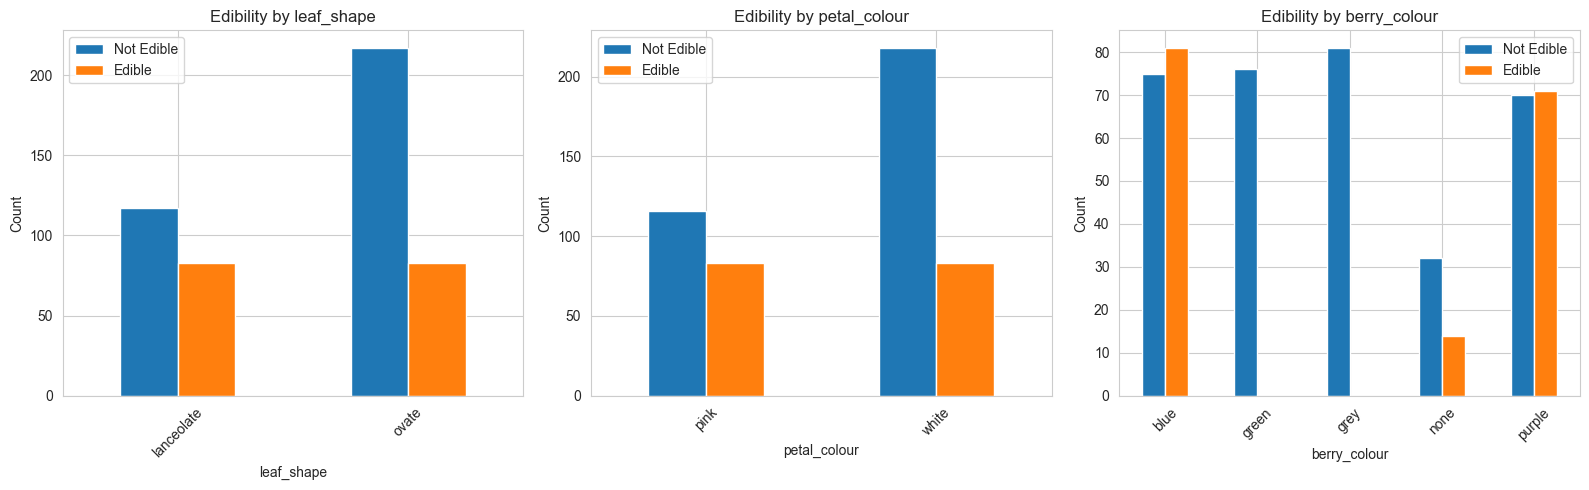

In [14]:
# Visualize the relationship between features and edibility
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(['leaf_shape', 'petal_colour', 'berry_colour']):
    ct = pd.crosstab(df_edible[col], df_edible['edible'])
    ct.plot(kind='bar', ax=axes[i], rot=45)
    axes[i].set_title(f'Edibility by {col}')
    axes[i].set_ylabel('Count')
    axes[i].legend(['Not Edible', 'Edible'])

plt.tight_layout()
plt.show()

In [15]:
# Encode categorical features for the classifiers
le_leaf = LabelEncoder()
le_petal = LabelEncoder()
le_berry = LabelEncoder()

X_edible = pd.DataFrame({
    'leaf_shape': le_leaf.fit_transform(df_edible['leaf_shape']),
    'petal_colour': le_petal.fit_transform(df_edible['petal_colour']),
    'berry_colour': le_berry.fit_transform(df_edible['berry_colour']),
})
y_edible = df_edible['edible'].astype(int)

print("Encoded features:")
print(X_edible.head())
print(f"\nLabel mappings:")
print(f"  leaf_shape:   {dict(zip(le_leaf.classes_, le_leaf.transform(le_leaf.classes_)))}")
print(f"  petal_colour: {dict(zip(le_petal.classes_, le_petal.transform(le_petal.classes_)))}")
print(f"  berry_colour: {dict(zip(le_berry.classes_, le_berry.transform(le_berry.classes_)))}")

# NOTE: Label encoding assigns integers (0, 1, 2, ...) which implies an ordering.
# This is fine for decision trees (they only check ≤ thresholds), but problematic
# for distance-based methods like KNN and SVM — they'd treat "blue=0, green=1, grey=2"
# as if grey is "further" from blue than green is. A more rigorous setup would be
# one-hot encoding + scaling in a pipeline. I keep label encoding here for simplicity,
# but this is a caveat to keep in mind when interpreting KNN/SVM results.

Encoded features:
   leaf_shape  petal_colour  berry_colour
0           0             1             0
1           0             1             1
2           0             1             0
3           1             1             3
4           0             1             2

Label mappings:
  leaf_shape:   {'lanceolate': np.int64(0), 'ovate': np.int64(1)}
  petal_colour: {'pink': np.int64(0), 'white': np.int64(1)}
  berry_colour: {'blue': np.int64(0), 'green': np.int64(1), 'grey': np.int64(2), 'none': np.int64(3), 'purple': np.int64(4)}


### Decision Tree

Starting with a decision tree because:
1. It handles categorical features naturally
2. It gives interpretable rules I could use in the wild
3. I can control complexity via max_depth to avoid overfitting

I'll try different depths and use cross-validation to find the sweet spot (bias-variance tradeoff: too shallow underfits, too deep overfits).

In [16]:
# Decision tree — let me try different depths to find the sweet spot
for depth in [2, 3, 4, 5, None]:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    scores = cross_val_score(dt, X_edible, y_edible, cv=5, scoring='accuracy')
    label = f"depth={depth}" if depth else "unlimited"
    print(f"  {label:>12}: accuracy = {scores.mean():.3f} (+/- {scores.std():.3f})")

       depth=2: accuracy = 0.914 (+/- 0.022)
       depth=3: accuracy = 0.962 (+/- 0.012)


       depth=4: accuracy = 0.962 (+/- 0.012)
       depth=5: accuracy = 0.962 (+/- 0.012)
     unlimited: accuracy = 0.962 (+/- 0.012)


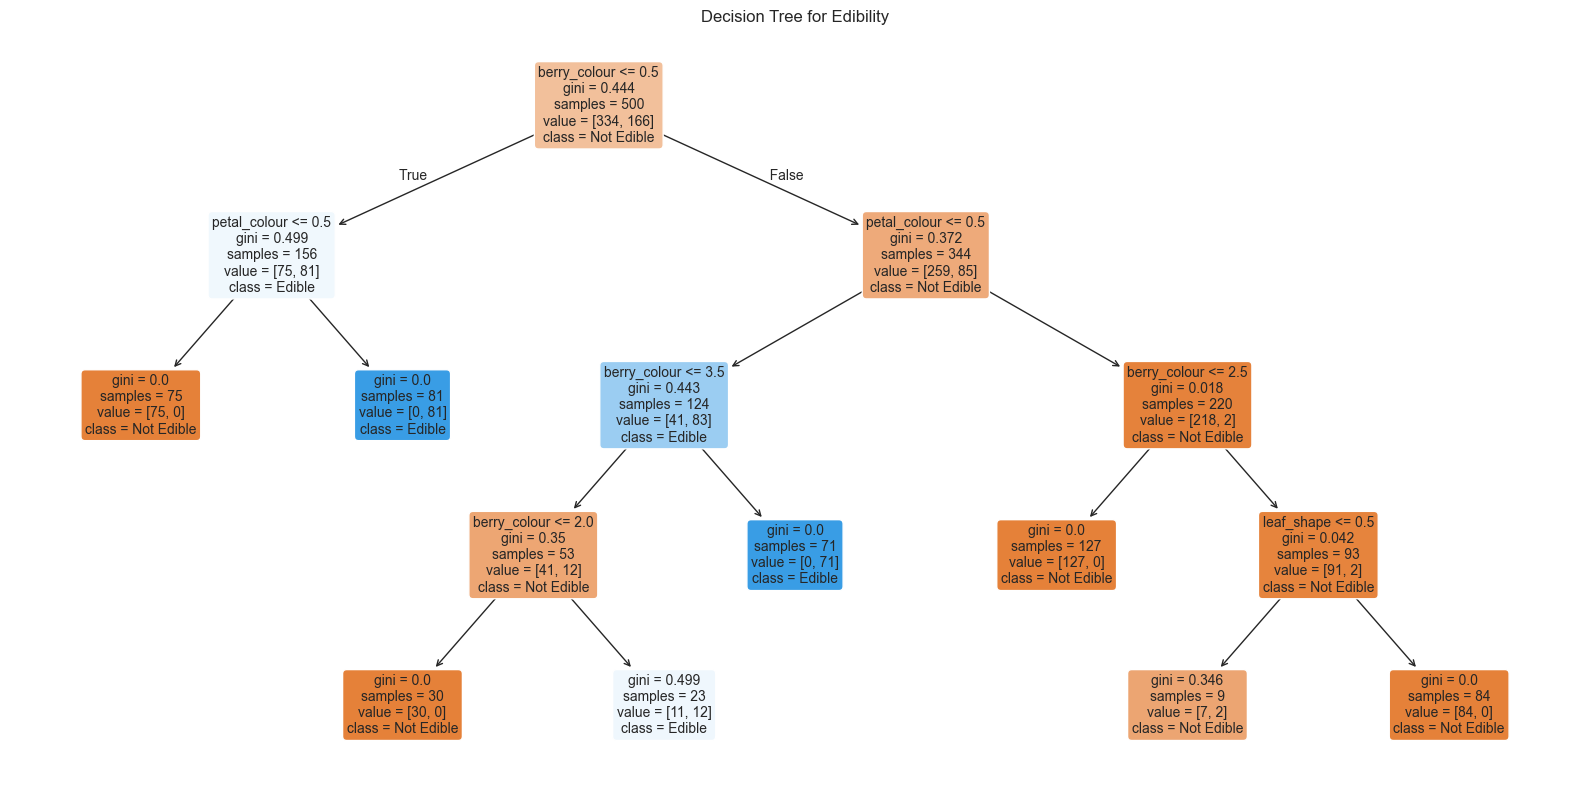

In [17]:
# Train the best tree on all data and visualize it
# (I'll pick a reasonable depth based on the CV results above)
dt_best = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_best.fit(X_edible, y_edible)

fig, ax = plt.subplots(figsize=(16, 8))
plot_tree(dt_best, 
          feature_names=['leaf_shape', 'petal_colour', 'berry_colour'],
          class_names=['Not Edible', 'Edible'],
          filled=True, rounded=True, ax=ax, fontsize=10)
ax.set_title("Decision Tree for Edibility")
plt.tight_layout()
plt.show()

In [18]:
# Print the rules as text — easier to read than the tree diagram
print("Decision rules for edibility:")
print("=" * 50)
print(export_text(dt_best, feature_names=['leaf_shape', 'petal_colour', 'berry_colour']))

# Feature importances — which feature matters most?
print("\nFeature importances:")
for feat, imp in zip(['leaf_shape', 'petal_colour', 'berry_colour'], dt_best.feature_importances_):
    print(f"  {feat}: {imp:.3f}")

Decision rules for edibility:
|--- berry_colour <= 0.50
|   |--- petal_colour <= 0.50
|   |   |--- class: 0
|   |--- petal_colour >  0.50
|   |   |--- class: 1
|--- berry_colour >  0.50
|   |--- petal_colour <= 0.50
|   |   |--- berry_colour <= 3.50
|   |   |   |--- berry_colour <= 2.00
|   |   |   |   |--- class: 0
|   |   |   |--- berry_colour >  2.00
|   |   |   |   |--- class: 1
|   |   |--- berry_colour >  3.50
|   |   |   |--- class: 1
|   |--- petal_colour >  0.50
|   |   |--- berry_colour <= 2.50
|   |   |   |--- class: 0
|   |   |--- berry_colour >  2.50
|   |   |   |--- leaf_shape <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- leaf_shape >  0.50
|   |   |   |   |--- class: 0


Feature importances:
  leaf_shape: 0.004
  petal_colour: 0.710
  berry_colour: 0.286


### Comparing classifiers

The decision tree works, but maybe other methods do better. Each has different assumptions:

- KNN: majority vote of nearest neighbors. No assumptions about boundary shape, but sensitive to irrelevant features and doesn't give rules.
- Naive Bayes: uses Bayes' theorem, assumes feature independence given the class. Fast but the independence assumption is strong.
- Random Forest: many trees on bootstrap samples, then majority vote. Reduces overfitting vs single tree, but loses interpretability.
- Gradient Boosting: trees built sequentially, each correcting the previous one's errors. Often very accurate but harder to tune.
- SVM (RBF kernel): finds max-margin boundary. Good theory but black box.

Note: KNN and SVM use distances, so label encoding (which assigns 0,1,2 to categories) can be unfair to them since it implies an ordering. The tree-based methods don't have this issue.

In [19]:
# Compare multiple classifiers using 5-fold cross-validation
classifiers = {
    "Decision Tree (depth=4)": DecisionTreeClassifier(max_depth=4, random_state=42),
    "KNN (k=5)": KNeighborsClassifier(n_neighbors=5),
    "KNN (k=3)": KNeighborsClassifier(n_neighbors=3),
    "Naive Bayes": GaussianNB(),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
    "SVM (rbf)": SVC(kernel='rbf', random_state=42),
}

results_edible = {}
print(f"{'Classifier':<25} | {'Accuracy':>10} | {'Std':>6}")
print("-" * 48)
for name, clf in classifiers.items():
    scores = cross_val_score(clf, X_edible, y_edible, cv=5, scoring='accuracy')
    results_edible[name] = scores.mean()
    print(f"{name:<25} | {scores.mean():>10.3f} | {scores.std():>6.3f}")

Classifier                |   Accuracy |    Std
------------------------------------------------


Decision Tree (depth=4)   |      0.962 |  0.012


KNN (k=5)                 |      0.976 |  0.014
KNN (k=3)                 |      0.968 |  0.007
Naive Bayes               |      0.668 |  0.004


Random Forest             |      0.964 |  0.014
Gradient Boosting         |      0.964 |  0.014
SVM (rbf)                 |      0.964 |  0.014


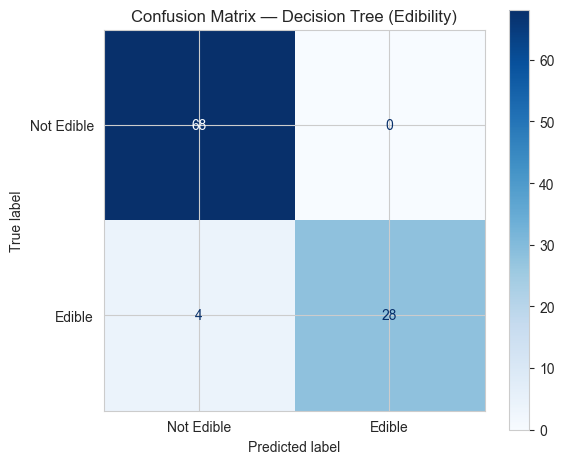

              precision    recall  f1-score   support

  Not Edible       0.94      1.00      0.97        68
      Edible       1.00      0.88      0.93        32

    accuracy                           0.96       100
   macro avg       0.97      0.94      0.95       100
weighted avg       0.96      0.96      0.96       100



In [20]:
# Confusion matrix for the decision tree to see what kinds of mistakes it makes
X_train, X_test, y_train, y_test = train_test_split(X_edible, y_edible, test_size=0.2, random_state=42)
dt_best.fit(X_train, y_train)
y_pred = dt_best.predict(X_test)

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['Not Edible', 'Edible'], ax=ax, cmap='Blues')
ax.set_title("Confusion Matrix — Decision Tree (Edibility)")
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred, target_names=['Not Edible', 'Edible']))

### Edibility takeaways

- The decision tree gives clear rules. The tree visualization shows exactly which feature combinations determine edibility.
- Feature importances show which visual cue matters most.
- Other classifiers hit similar accuracy, but the decision tree is the most practical one for island survival.
- Caveat: KNN/SVM results may be slightly unfair due to label encoding injecting fake ordering into categorical features. A proper setup would use one-hot encoding + scaling. Trees and Random Forests don't have this issue.
- From the confusion matrix: precision on the "Edible" class is the survival-critical metric. A false positive (eating something poisonous) is much worse than a false negative (skipping an edible berry).

---
# Part 3: Species Classification

A previous expedition identified 5 species. Can I classify them from leaf shape, petal colour, berry colour?

The tricky part: bushes rarely have more than one of leaves, petals, and berries at the same time. So I also need to test classification with only one visual feature plus general features (age, height, soil).

I'll also compare two strategies for predicting edibility from partial info:
1. Predict edibility directly from the partial features
2. Predict species first, then map species to edibility

The second approach is interesting because species might be a cleaner intermediate target. But if species prediction is noisy, errors compound.

In [21]:
# Let's look at the species data
print("Species in the dataset:")
print(df_species['species'].value_counts())
print(f"\nFeature combinations:")
print(df_species.groupby(['leaf_shape', 'petal_colour', 'berry_colour', 'species']).size().reset_index(name='count').to_string())

# Also check: does species perfectly determine edibility?
print("\n\nSpecies vs Edibility (from complete dataset):")
print(df_complete.groupby('species')['edible'].mean().round(3))

Species in the dataset:
species
berrius elephas        103
berrius codiae         101
berrius delphinorum    100
berrius boethiae        99
berrius actius          97
Name: count, dtype: int64

Feature combinations:
    leaf_shape petal_colour berry_colour              species  count
0   lanceolate        white         blue       berrius actius     81
1   lanceolate        white        green       berrius actius     14
2   lanceolate        white        green      berrius elephas     15
3   lanceolate        white         grey      berrius elephas     81
4   lanceolate        white         none       berrius actius      2
5   lanceolate        white         none      berrius elephas      7
6        ovate         pink         blue  berrius delphinorum     75
7        ovate         pink        green     berrius boethiae     16
8        ovate         pink        green  berrius delphinorum     14
9        ovate         pink         none     berrius boethiae     12
10       ovate         pi

### All three visual features

First the easy case: all three features available. This is a 5-class problem so it should be harder than binary edibility.

In [22]:
# Encode species features
le_species = LabelEncoder()
X_species = pd.DataFrame({
    'leaf_shape': le_leaf.transform(df_species['leaf_shape']),
    'petal_colour': le_petal.transform(df_species['petal_colour']),
    'berry_colour': le_berry.transform(df_species['berry_colour']),
})
y_species = le_species.fit_transform(df_species['species'])

print("Species labels:", dict(zip(le_species.classes_, range(len(le_species.classes_)))))

# Compare classifiers on full-feature species classification
classifiers_species = {
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "KNN (k=5)": KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes": GaussianNB(),
    "SVM": SVC(kernel='rbf', random_state=42),
}

print(f"\n{'Classifier':<20} | {'Accuracy':>10} | {'Std':>6}")
print("-" * 42)
for name, clf in classifiers_species.items():
    scores = cross_val_score(clf, X_species, y_species, cv=5, scoring='accuracy')
    print(f"{name:<20} | {scores.mean():>10.3f} | {scores.std():>6.3f}")

Species labels: {'berrius actius': 0, 'berrius boethiae': 1, 'berrius codiae': 2, 'berrius delphinorum': 3, 'berrius elephas': 4}

Classifier           |   Accuracy |    Std
------------------------------------------
Decision Tree        |      0.904 |  0.019


Random Forest        |      0.906 |  0.016
KNN (k=5)            |      0.912 |  0.013
Naive Bayes          |      0.912 |  0.016
SVM                  |      0.910 |  0.011


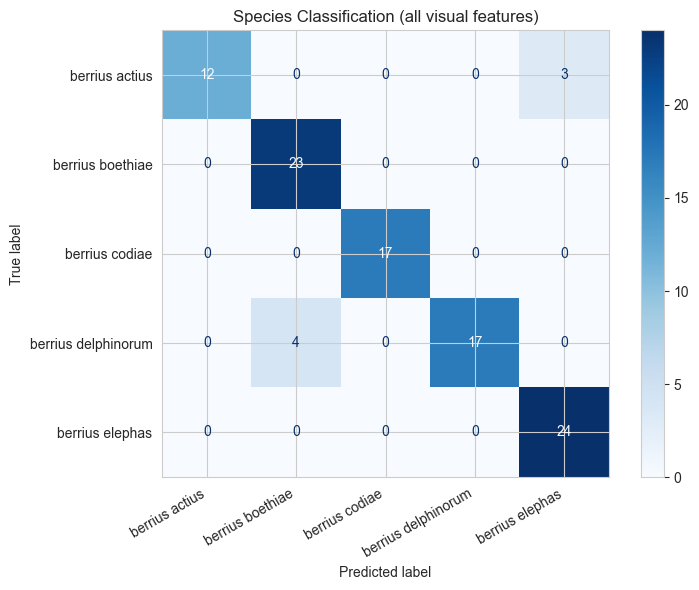

In [23]:
# Confusion matrix for species classification
X_tr, X_te, y_tr, y_te = train_test_split(X_species, y_species, test_size=0.2, random_state=42)
rf_species = RandomForestClassifier(n_estimators=100, random_state=42)
rf_species.fit(X_tr, y_tr)
y_pred_sp = rf_species.predict(X_te)

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_te, y_pred_sp, display_labels=le_species.classes_, ax=ax, cmap='Blues')
ax.set_title("Species Classification (all visual features)")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

### Partial features

Now the realistic scenario. Only one visual feature at a time, plus age, height, soil quality.

The datasets are:
- `df_berry`: berry_colour + berry_size + age, height, soil_quality
- `df_leaf`: leaf_shape + leaf_size + age, height, soil_quality
- `df_petal`: petal_colour + petal_size + age, height, soil_quality

For each I'll predict species and edibility, then compare direct vs indirect edibility.

In [24]:
# Helper: prepare features for a partial dataset (encode categoricals, keep numerics)
def prepare_partial(df, cat_cols, num_cols):
    """Encode categorical columns and combine with numeric columns."""
    parts = []
    encoders = {}
    for col in cat_cols:
        le = LabelEncoder()
        parts.append(pd.Series(le.fit_transform(df[col]), name=col))
        encoders[col] = le
    for col in num_cols:
        parts.append(df[col].reset_index(drop=True))
    return pd.concat(parts, axis=1), encoders

# Prepare all three partial datasets
datasets = {}

# Berry dataset
X_berry, _ = prepare_partial(df_berry, ['berry_colour'], ['age', 'height', 'soil_quality', 'berry_size'])
datasets['Berry'] = (X_berry, df_berry['species'], df_berry['edible'].astype(int))

# Leaf dataset
X_leaf, _ = prepare_partial(df_leaf, ['leaf_shape'], ['age', 'height', 'soil_quality', 'leaf_size'])
datasets['Leaf'] = (X_leaf, df_leaf['species'], df_leaf['edible'].astype(int))

# Petal dataset
X_petal, _ = prepare_partial(df_petal, ['petal_colour'], ['age', 'height', 'soil_quality', 'petal_size'])
datasets['Petal'] = (X_petal, df_petal['species'], df_petal['edible'].astype(int))

for name, (X, y_sp, y_ed) in datasets.items():
    print(f"{name}: {X.shape[1]} features, {len(X)} samples")
    print(f"  Features: {list(X.columns)}")
    print(f"  Species: {y_sp.nunique()} unique, Edible: {y_ed.sum()}/{len(y_ed)}\n")

Berry: 5 features, 500 samples
  Features: ['berry_colour', 'age', 'height', 'soil_quality', 'berry_size']
  Species: 5 unique, Edible: 166/500

Leaf: 5 features, 500 samples
  Features: ['leaf_shape', 'age', 'height', 'soil_quality', 'leaf_size']
  Species: 5 unique, Edible: 166/500

Petal: 5 features, 500 samples
  Features: ['petal_colour', 'age', 'height', 'soil_quality', 'petal_size']
  Species: 5 unique, Edible: 166/500



In [25]:
# For each partial dataset, compare:
#   1) Species classification accuracy
#   2) Direct edibility prediction
#   3) Indirect: predict species first, then map to edibility

# First, build the species→edibility mapping from the complete dataset
species_edible_map = df_complete.groupby('species')['edible'].mean().round(0).astype(bool).to_dict()
print("Species → Edible mapping:")
for sp, ed in species_edible_map.items():
    print(f"  {sp}: {'Edible' if ed else 'NOT edible'}")

le_sp_partial = LabelEncoder()
le_sp_partial.fit(df_complete['species'])

print("\n" + "=" * 70)
print(f"{'Dataset':<8} | {'Classifier':<15} | {'Species Acc':>11} | {'Direct Edib':>11} | {'Indirect Edib':>13}")
print("=" * 70)

# Use Random Forest as the main classifier — it's generally robust
for ds_name, (X, y_sp_raw, y_ed) in datasets.items():
    y_sp = le_sp_partial.transform(y_sp_raw)
    
    for clf_name, clf_cls in [("Decision Tree", lambda: DecisionTreeClassifier(max_depth=5, random_state=42)),
                               ("Random Forest", lambda: RandomForestClassifier(n_estimators=100, random_state=42)),
                               ("KNN (k=5)", lambda: KNeighborsClassifier(n_neighbors=5))]:
        # Species accuracy
        sp_scores = cross_val_score(clf_cls(), X, y_sp, cv=5, scoring='accuracy')
        
        # Direct edibility accuracy
        ed_scores = cross_val_score(clf_cls(), X, y_ed, cv=5, scoring='accuracy')
        
        # Indirect: predict species, then map to edibility
        # Need to do this manually with cross-validation
        from sklearn.model_selection import StratifiedKFold
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        indirect_accs = []
        for train_idx, test_idx in skf.split(X, y_ed):
            clf_sp = clf_cls()
            clf_sp.fit(X.iloc[train_idx], y_sp[train_idx])
            sp_pred = clf_sp.predict(X.iloc[test_idx])
            # Map predicted species to edibility
            sp_names_pred = le_sp_partial.inverse_transform(sp_pred)
            ed_pred_indirect = np.array([species_edible_map.get(s, False) for s in sp_names_pred]).astype(int)
            indirect_accs.append(accuracy_score(y_ed.iloc[test_idx], ed_pred_indirect))
        
        indirect_acc = np.mean(indirect_accs)
        
        print(f"{ds_name:<8} | {clf_name:<15} | {sp_scores.mean():>11.3f} | {ed_scores.mean():>11.3f} | {indirect_acc:>13.3f}")
    print("-" * 70)

Species → Edible mapping:
  berrius actius: Edible
  berrius boethiae: Edible
  berrius codiae: NOT edible
  berrius delphinorum: NOT edible
  berrius elephas: NOT edible

Dataset  | Classifier      | Species Acc | Direct Edib | Indirect Edib


Berry    | Decision Tree   |       0.764 |       0.878 |         0.768


Berry    | Random Forest   |       0.818 |       0.914 |         0.854
Berry    | KNN (k=5)       |       0.498 |       0.686 |         0.638
----------------------------------------------------------------------
Leaf     | Decision Tree   |       0.894 |       0.830 |         0.874


Leaf     | Random Forest   |       0.914 |       0.892 |         0.890
Leaf     | KNN (k=5)       |       0.542 |       0.700 |         0.614
----------------------------------------------------------------------
Petal    | Decision Tree   |       0.782 |       0.786 |         0.744


Petal    | Random Forest   |       0.812 |       0.832 |         0.786
Petal    | KNN (k=5)       |       0.434 |       0.636 |         0.588
----------------------------------------------------------------------


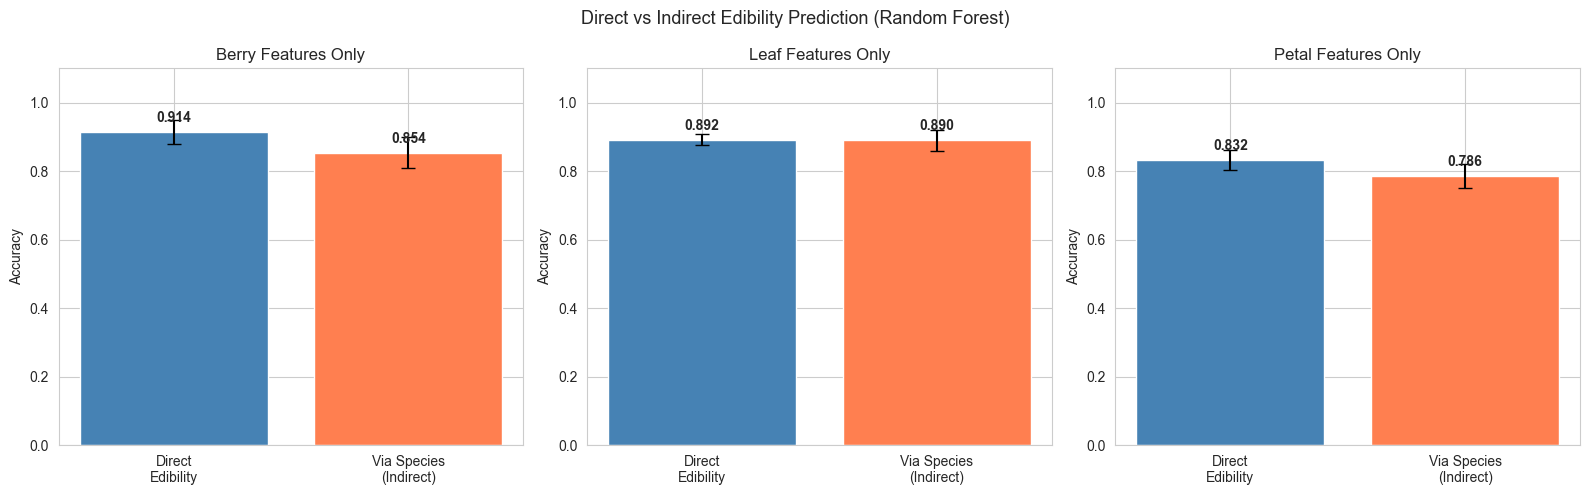

In [26]:
# Visualize the comparison: direct vs indirect edibility for each dataset
# Using Random Forest as our representative classifier

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, (ds_name, (X, y_sp_raw, y_ed)) in enumerate(datasets.items()):
    y_sp = le_sp_partial.transform(y_sp_raw)
    ax = axes[idx]
    
    # Direct edibility
    rf_direct = RandomForestClassifier(n_estimators=100, random_state=42)
    direct_scores = cross_val_score(rf_direct, X, y_ed, cv=5, scoring='accuracy')
    
    # Indirect via species
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    indirect_scores = []
    for train_idx, test_idx in skf.split(X, y_ed):
        rf_sp = RandomForestClassifier(n_estimators=100, random_state=42)
        rf_sp.fit(X.iloc[train_idx], y_sp[train_idx])
        sp_pred = rf_sp.predict(X.iloc[test_idx])
        sp_names_pred = le_sp_partial.inverse_transform(sp_pred)
        ed_pred = np.array([species_edible_map.get(s, False) for s in sp_names_pred]).astype(int)
        indirect_scores.append(accuracy_score(y_ed.iloc[test_idx], ed_pred))
    
    bars = ax.bar(['Direct\nEdibility', 'Via Species\n(Indirect)'], 
                  [direct_scores.mean(), np.mean(indirect_scores)],
                  yerr=[direct_scores.std(), np.std(indirect_scores)],
                  color=['steelblue', 'coral'], capsize=5)
    ax.set_ylim(0, 1.1)
    ax.set_title(f'{ds_name} Features Only')
    ax.set_ylabel('Accuracy')
    
    # Add value labels on bars
    for bar, val in zip(bars, [direct_scores.mean(), np.mean(indirect_scores)]):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02, 
                f'{val:.3f}', ha='center', va='bottom', fontweight='bold')

plt.suptitle("Direct vs Indirect Edibility Prediction (Random Forest)", fontsize=13)
plt.tight_layout()
plt.show()

### Species takeaways

- With all three visual features, species classification works well (~91%).
- With partial features, accuracy drops but is still usable. The table shows which single characteristic is most informative.
- I chose to compare direct vs indirect edibility because this is exactly the real field scenario: if species predictions are noisy, those mistakes propagate into the final edible/not-edible decision.
- Direct edibility prediction often beats the indirect (species then map to edible) approach, because errors in species prediction cascade into wrong edibility calls. The indirect approach only wins when species is substantially easier to predict than edibility itself.

---
# Part 4: Berry Size Regression

Berries are my main food source, so I want to predict how big they'll be from the other features.

I'll try Linear Regression (gives an explicit formula), Ridge and Lasso (regularized versions that handle correlated features and can do feature selection), plus Random Forest and Gradient Boosting (capture non-linear effects but no formula).

Need to one-hot encode the categorical features since regression needs numbers. Using `drop_first=True` to avoid multicollinearity.

Sub-questions: does filtering to edible-only help? Can I get a usable formula? How much accuracy do I lose without soil quality?

In [27]:
# Prepare the regression dataset
# Target: berry_size
# Features: everything else

df_reg = df_complete.copy()

# One-hot encode categoricals for regression (LabelEncoder would imply ordering)
df_reg_encoded = pd.get_dummies(df_reg, columns=['leaf_shape', 'petal_colour', 'berry_colour', 'species'], 
                                 drop_first=True, dtype=int)
# Convert bool to int so all classifiers can handle it
df_reg_encoded['edible'] = df_reg_encoded['edible'].astype(int)

# Separate features and target
target = 'berry_size'
feature_cols = [c for c in df_reg_encoded.columns if c != target]
X_reg = df_reg_encoded[feature_cols]
y_reg = df_reg_encoded[target]

print(f"Regression dataset: {X_reg.shape[0]} samples, {X_reg.shape[1]} features")
print(f"\nFeatures: {list(X_reg.columns)}")
print(f"\nBerry size distribution:")
print(y_reg.describe().round(2))

Regression dataset: 500 samples, 16 features

Features: ['age', 'leaf_size', 'petal_size', 'height', 'edible', 'soil_quality', 'leaf_shape_ovate', 'petal_colour_white', 'berry_colour_green', 'berry_colour_grey', 'berry_colour_none', 'berry_colour_purple', 'species_berrius boethiae', 'species_berrius codiae', 'species_berrius delphinorum', 'species_berrius elephas']

Berry size distribution:
count    500.00
mean       7.31
std        2.82
min        0.00
25%        6.53
50%        7.85
75%        9.04
max       12.56
Name: berry_size, dtype: float64


In [28]:
# Compare regression methods using cross-validation
from sklearn.model_selection import cross_val_score

regressors = {
    "Linear Regression": LinearRegression(),
    "Ridge (alpha=1)": Ridge(alpha=1.0),
    "Ridge (alpha=10)": Ridge(alpha=10.0),
    "Lasso (alpha=0.1)": Lasso(alpha=0.1),
    "Lasso (alpha=1)": Lasso(alpha=1.0),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42),
}

print("=== All berries ===")
print(f"{'Method':<25} | {'R² (CV)':>10} | {'RMSE (CV)':>10}")
print("-" * 50)

results_all = {}
for name, reg in regressors.items():
    r2_scores = cross_val_score(reg, X_reg, y_reg, cv=5, scoring='r2')
    neg_mse = cross_val_score(reg, X_reg, y_reg, cv=5, scoring='neg_mean_squared_error')
    rmse = np.sqrt(-neg_mse.mean())
    results_all[name] = (r2_scores.mean(), rmse)
    print(f"{name:<25} | {r2_scores.mean():>10.3f} | {rmse:>10.3f}")

=== All berries ===
Method                    |    R² (CV) |  RMSE (CV)
--------------------------------------------------
Linear Regression         |      0.875 |      0.979
Ridge (alpha=1)           |      0.875 |      0.983
Ridge (alpha=10)          |      0.827 |      1.161
Lasso (alpha=0.1)         |      0.841 |      1.113
Lasso (alpha=1)           |      0.190 |      2.524


Random Forest             |      0.876 |      0.977


Gradient Boosting         |      0.872 |      0.986


### Edible berries only

Who cares about poisonous berry size? Let me repeat with only edible plants and see if the relationship is cleaner.

In [29]:
# Filter to edible only
df_edible_only = df_reg_encoded[df_reg_encoded['edible'] == True].copy()
X_reg_edible = df_edible_only[feature_cols]
y_reg_edible = df_edible_only[target]

print(f"Edible berries: {len(X_reg_edible)} samples (vs {len(X_reg)} total)")

print(f"\n=== Edible berries only ===")
print(f"{'Method':<25} | {'R² (CV)':>10} | {'RMSE (CV)':>10}")
print("-" * 50)

results_edible_reg = {}
for name, reg in regressors.items():
    r2_scores = cross_val_score(reg, X_reg_edible, y_reg_edible, cv=5, scoring='r2')
    neg_mse = cross_val_score(reg, X_reg_edible, y_reg_edible, cv=5, scoring='neg_mean_squared_error')
    rmse = np.sqrt(-neg_mse.mean())
    results_edible_reg[name] = (r2_scores.mean(), rmse)
    print(f"{name:<25} | {r2_scores.mean():>10.3f} | {rmse:>10.3f}")

# Compare side by side
print(f"\n=== Comparison: All vs Edible Only ===")
print(f"{'Method':<25} | {'All R²':>8} | {'Edible R²':>10} | {'Improvement':>11}")
print("-" * 60)
for name in regressors:
    r2_all = results_all[name][0]
    r2_ed = results_edible_reg[name][0]
    diff = r2_ed - r2_all
    print(f"{name:<25} | {r2_all:>8.3f} | {r2_ed:>10.3f} | {diff:>+11.3f}")

Edible berries: 166 samples (vs 500 total)

=== Edible berries only ===
Method                    |    R² (CV) |  RMSE (CV)
--------------------------------------------------
Linear Regression         |      0.855 |      0.995
Ridge (alpha=1)           |      0.839 |      1.053
Ridge (alpha=10)          |      0.716 |      1.412
Lasso (alpha=0.1)         |      0.820 |      1.114
Lasso (alpha=1)           |      0.279 |      2.237


Random Forest             |      0.841 |      1.040


Gradient Boosting         |      0.822 |      1.107

=== Comparison: All vs Edible Only ===
Method                    |   All R² |  Edible R² | Improvement
------------------------------------------------------------
Linear Regression         |    0.875 |      0.855 |      -0.021
Ridge (alpha=1)           |    0.875 |      0.839 |      -0.035
Ridge (alpha=10)          |    0.827 |      0.716 |      -0.111
Lasso (alpha=0.1)         |    0.841 |      0.820 |      -0.020
Lasso (alpha=1)           |    0.190 |      0.279 |      +0.089
Random Forest             |    0.876 |      0.841 |      -0.035
Gradient Boosting         |    0.872 |      0.822 |      -0.051


### Explicit formula

Linear regression gives a closed-form expression I can write on paper and use without a computer. Fitting on all data to extract coefficients (performance estimate comes from CV above, not the training R² here).

In [30]:
# Fit on all data to get the coefficients for the formula
lr = LinearRegression()
lr.fit(X_reg, y_reg)

print("Explicit formula (all berries):")
print(f"  berry_size = {lr.intercept_:.2f}", end="")
for feat, coef in sorted(zip(X_reg.columns, lr.coef_), key=lambda x: abs(x[1]), reverse=True):
    if abs(coef) > 0.01:
        print(f" {'+' if coef > 0 else '-'} {abs(coef):.2f}*{feat}", end="")
print()
print(f"  (Training R² = {lr.score(X_reg, y_reg):.3f} — but use CV R² from above for real performance)")

# Same for edible only
lr_ed = LinearRegression()
lr_ed.fit(X_reg_edible, y_reg_edible)

print(f"\nExplicit formula (edible only):")
print(f"  berry_size = {lr_ed.intercept_:.2f}", end="")
for feat, coef in sorted(zip(X_reg_edible.columns, lr_ed.coef_), key=lambda x: abs(x[1]), reverse=True):
    if abs(coef) > 0.01:
        print(f" {'+' if coef > 0 else '-'} {abs(coef):.2f}*{feat}", end="")
print()
print(f"  (Training R² = {lr_ed.score(X_reg_edible, y_reg_edible):.3f})")

Explicit formula (all berries):
  berry_size = 3.30 - 8.31*berry_colour_none + 1.20*soil_quality - 0.86*species_berrius codiae + 0.76*species_berrius delphinorum - 0.49*leaf_shape_ovate + 0.43*berry_colour_grey - 0.39*species_berrius boethiae - 0.37*petal_colour_white + 0.33*species_berrius elephas - 0.11*berry_colour_green - 0.09*berry_colour_purple + 0.07*edible - 0.04*age + 0.02*petal_size
  (Training R² = 0.887 — but use CV R² from above for real performance)

Explicit formula (edible only):
  berry_size = 2.89 - 8.59*berry_colour_none + 1.50*soil_quality - 0.47*berry_colour_purple - 0.14*petal_size - 0.04*age - 0.04*leaf_size - 0.02*species_berrius boethiae + 0.02*petal_colour_white - 0.02*leaf_shape_ovate
  (Training R² = 0.871)


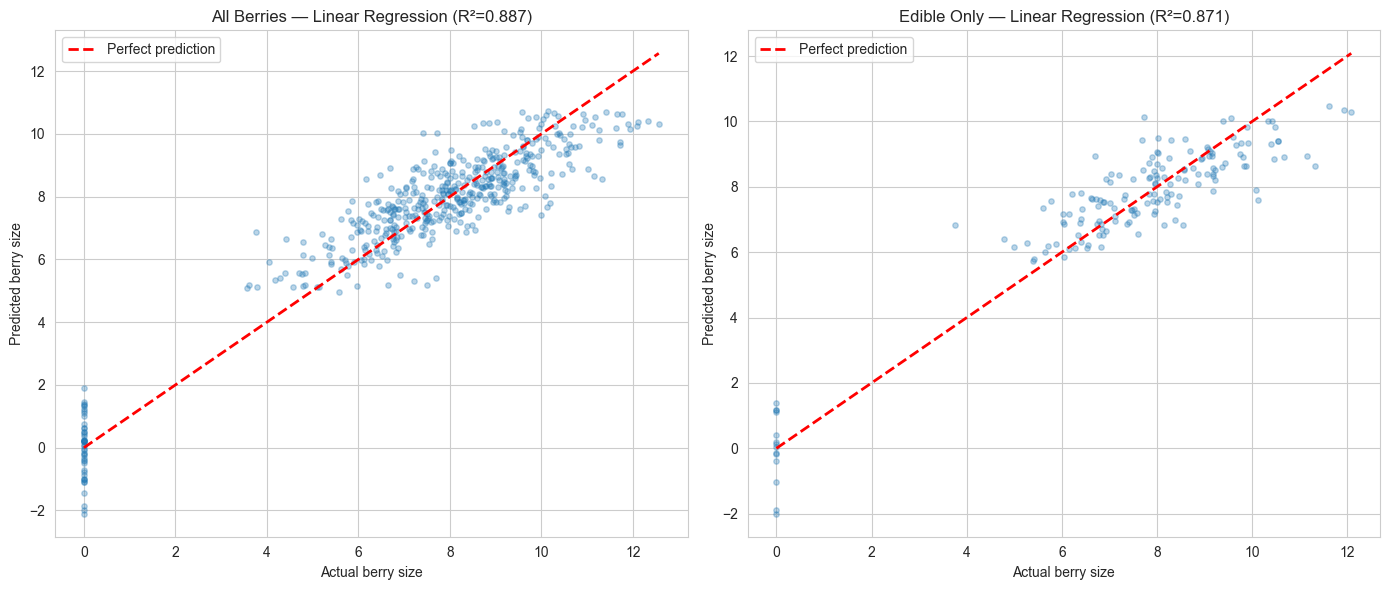

In [31]:
# Predicted vs actual plot — a classic way to visualize regression quality
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for idx, (title, X_data, y_data) in enumerate([("All Berries", X_reg, y_reg), 
                                                  ("Edible Only", X_reg_edible, y_reg_edible)]):
    ax = axes[idx]
    lr_temp = LinearRegression()
    lr_temp.fit(X_data, y_data)
    y_pred = lr_temp.predict(X_data)
    
    ax.scatter(y_data, y_pred, alpha=0.3, s=15)
    ax.plot([y_data.min(), y_data.max()], [y_data.min(), y_data.max()], 'r--', lw=2, label='Perfect prediction')
    ax.set_xlabel('Actual berry size')
    ax.set_ylabel('Predicted berry size')
    ax.set_title(f'{title} — Linear Regression (R²={lr_temp.score(X_data, y_data):.3f})')
    ax.legend()

plt.tight_layout()
plt.show()

### Feature subsets

Soil quality is hard to assess in the wild. Can I still predict berry size without it? Let me systematically drop features and check the impact.

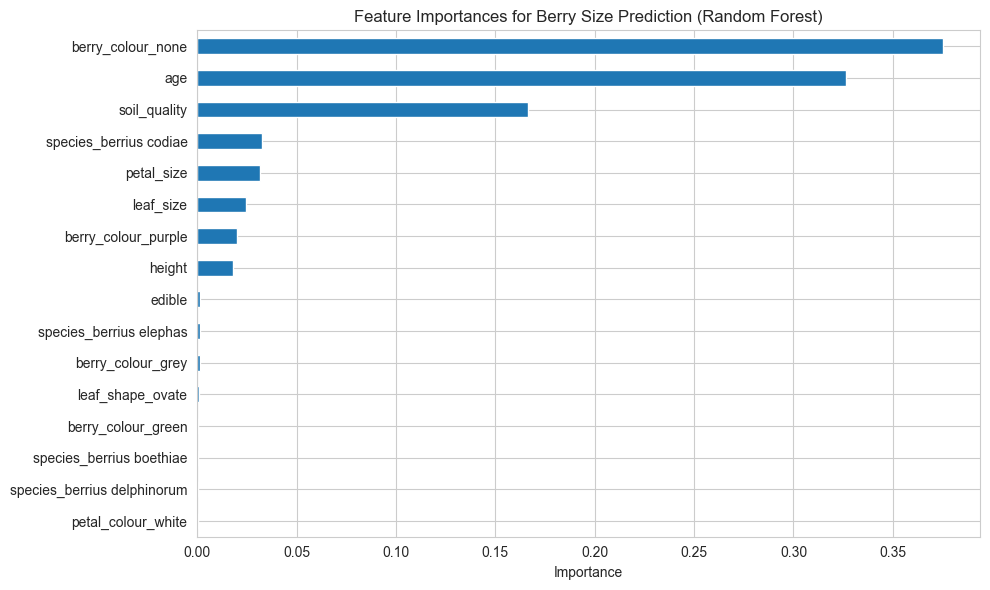

Top features:
  berry_colour_none: 0.3751
  age: 0.3262
  soil_quality: 0.1666
  species_berrius codiae: 0.0324
  petal_size: 0.0316
  leaf_size: 0.0246
  berry_colour_purple: 0.0198
  height: 0.0178


In [32]:
# Feature importance from Random Forest — tells us which features matter most
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_reg, y_reg)

importances = pd.Series(rf_reg.feature_importances_, index=X_reg.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
importances.plot(kind='barh', ax=ax)
ax.set_title("Feature Importances for Berry Size Prediction (Random Forest)")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

print("Top features:")
for feat, imp in importances.sort_values(ascending=False).head(8).items():
    print(f"  {feat}: {imp:.4f}")

In [33]:
# Systematic feature dropping: what happens if we remove features one at a time?
# Start with the "hard to measure" ones the assignment hints at

# Define groups of features to test
# First: specific drops the assignment asks about
feature_subsets = {
    "All features": list(X_reg.columns),
    "Without soil_quality": [c for c in X_reg.columns if 'soil_quality' not in c],
    "Without species": [c for c in X_reg.columns if 'species' not in c],
    "Without categorical": [c for c in X_reg.columns if c in ['age', 'leaf_size', 'petal_size', 'height', 'soil_quality', 'edible']],
    "Numeric only (no soil)": [c for c in X_reg.columns if c in ['age', 'leaf_size', 'petal_size', 'height', 'edible']],
    "Just age + height": ['age', 'height'],
    "age + height + edible": ['age', 'height', 'edible'],
}

print(f"{'Feature Subset':<30} | {'# Feats':>7} | {'LR R²':>7} | {'RF R²':>7} | {'GB R²':>7}")
print("=" * 75)

for name, cols in feature_subsets.items():
    valid_cols = [c for c in cols if c in X_reg.columns]
    X_sub = X_reg[valid_cols]
    
    lr_r2 = cross_val_score(LinearRegression(), X_sub, y_reg, cv=5, scoring='r2').mean()
    rf_r2 = cross_val_score(RandomForestRegressor(n_estimators=100, random_state=42), X_sub, y_reg, cv=5, scoring='r2').mean()
    gb_r2 = cross_val_score(GradientBoostingRegressor(n_estimators=100, random_state=42), X_sub, y_reg, cv=5, scoring='r2').mean()
    
    print(f"{name:<30} | {len(valid_cols):>7} | {lr_r2:>7.3f} | {rf_r2:>7.3f} | {gb_r2:>7.3f}")

Feature Subset                 | # Feats |   LR R² |   RF R² |   GB R²


All features                   |      16 |   0.875 |   0.876 |   0.872


Without soil_quality           |      15 |   0.861 |   0.856 |   0.849


Without species                |      12 |   0.875 |   0.874 |   0.869


Without categorical            |       6 |   0.229 |   0.861 |   0.855


Numeric only (no soil)         |       5 |   0.219 |   0.840 |   0.827


Just age + height              |       2 |   0.134 |   0.626 |   0.629


age + height + edible          |       3 |   0.138 |   0.652 |   0.637


In [34]:
# Simplified explicit formula WITHOUT soil_quality (for use in the wild)
cols_no_soil = [c for c in X_reg.columns if 'soil_quality' not in c]
X_no_soil = X_reg[cols_no_soil]

lr_no_soil = LinearRegression()
lr_no_soil.fit(X_no_soil, y_reg)

print("Simplified formula (no soil_quality):")
print(f"berry_size = {lr_no_soil.intercept_:.4f}")
for feat, coef in sorted(zip(cols_no_soil, lr_no_soil.coef_), key=lambda x: abs(x[1]), reverse=True):
    if abs(coef) > 0.001:
        sign = "+" if coef > 0 else "-"
        print(f"    {sign} {abs(coef):.4f} * {feat}")

r2_no_soil = cross_val_score(LinearRegression(), X_no_soil, y_reg, cv=5, scoring='r2').mean()
print(f"\nCross-validated R²: {r2_no_soil:.4f}")

Simplified formula (no soil_quality):
berry_size = 3.8302
    - 8.3159 * berry_colour_none
    + 1.4854 * species_berrius elephas
    + 1.1051 * species_berrius boethiae
    - 1.0543 * species_berrius codiae
    + 0.9812 * petal_size
    - 0.7431 * petal_colour_white
    - 0.3620 * species_berrius delphinorum
    - 0.3111 * leaf_shape_ovate
    + 0.2982 * berry_colour_grey
    - 0.2313 * berry_colour_green
    - 0.1760 * berry_colour_purple
    + 0.0687 * leaf_size
    - 0.0618 * age
    - 0.0319 * edible
    + 0.0015 * height

Cross-validated R²: 0.8607


### Regression takeaways

- Tree-based methods slightly outperform linear regression, suggesting non-linear relationships in the data.
- But linear regression still gives R² ~0.875 (CV) and an explicit formula, which is the main deliverable here.
- I expected edible-only filtering to improve performance, but it didn't clearly help; the sample-size drop (500 to ~166) seems to hurt more than the gain in homogeneity.
- Dropping soil_quality has a moderate impact. I kept this analysis because it's a practical trade-off: slightly lower accuracy might be worth it if soil is hard to assess reliably in the field.
- Ridge and Lasso perform similarly to plain linear regression here, suggesting multicollinearity isn't a major issue in this dataset.

---
# Summary

1. Clustering showed natural groups in the data, with k around 4-5 plausible for the richer feature sets (while some subsets favor k=2). Growth_rate helps in some subsets but not universally.
2. Edibility: decision tree at depth 3 gets ~96% accuracy with simple rules. Other classifiers are comparable, but I prioritized the tree because it's easiest to explain and use without a computer.
3. Species: ~91% with all visual features, drops with partial info. Direct edibility prediction often beats the indirect (species first) approach because species errors propagate.
4. Berry size: linear regression gives R² ~0.875 and an explicit formula. Ensemble methods are slightly better but lose the formula. Dropping soil quality has a moderate cost, which may be acceptable in field use.